# Marcelo Guesser — Walkthrough

This notebook walks through the **complete architecture** of the **Router-based Multi-Strategy**: an approach that runs multi-strategy QA agent entirely on a CPU-only machine with RAM limitations and just using API calls (only DuckDuckGO) as a fallback.

# Notebook Parts

1. **The problem** and the hardware constraints that shaped every design decision
2. **The Router-based Hybrid architecture** that picks a different strategy per theme
3. **Ingestion** of knowledge into ChromaDB for the RAG-enabled themes
4. **Strategy 1 — RAG** (used for Science, Entertainment, Philosophy)
5. **Strategy 2 — Web Search** (used for History, News)
6. **Math theme**: The nightmare theme.
7. The **integrated `GuesserEngine`** orchestrating everything
8. **Limitations** and what we could not solve

---

obs: **Claude Code** was used to
- _help developing the diagrams to make the understanding of the architecture easier._
- _help generating code for the analysis like extracting metrics (time, accuracy, model size etc all separated by theme)_

## Part 1 — The Constraints

### The hardware
Everything runs locally on a **Snapdragon X Elite** machine (Windows on ARM, CPU-only — Ollama does not support the integrated Adreno GPU nor the Hexagon NPU).

### The constraints that shaped the design

| Limitation | Impact |
|---|---|
| **RAM pressure** (~8 GB free) | Cannot fit 7B+ models — must pick small, specialized models per theme |
| **Cold-start overhead** | Models get evicted from memory → 2–5s overhead per swap |
| **CPU-only inference** (no GPU) | ~3–5 tok/s for 3B models, long contexts blow up prompt processing and also cause Timeout |

In [1]:
# Setup: ensure both project and Marcelo are in sys.path
import os, sys
notebook_dir = os.path.abspath(os.getcwd())
marcelo_root = notebook_dir if notebook_dir.endswith('Marcelo') else os.path.join(notebook_dir, 'Marcelo')
project_root = os.path.dirname(marcelo_root)
for p in (project_root, marcelo_root):
    if p not in sys.path:
        sys.path.insert(0, p)

print('project_root:', project_root)
print('marcelo_root:', marcelo_root)

project_root: c:\Users\marce\Desktop\Code\NLP_Assignment
marcelo_root: c:\Users\marce\Desktop\Code\NLP_Assignment\Marcelo


In [2]:
# Sanity check: which models are currently loaded in Ollama?
import subprocess
try:
    result = subprocess.run(['ollama', 'ps'], capture_output=True, text=True, check=True)
    print(result.stdout)
except Exception as e:
    print(f'Could not query Ollama (is it running?): {e}')

NAME               ID              SIZE      PROCESSOR    CONTEXT    UNTIL   
llama3.2:latest    a80c4f17acd5    4.8 GB    100% CPU     4096       Forever    
qwen2-math:1.5b    a4fdda0c6cc5    1.6 GB    100% CPU     4096       Forever    
qwen2.5:0.5b       a8b0c5157701    693 MB    100% CPU     4096       Forever    



## Part 2 — The Architecture: Router-based Hybrid

Instead of using one large general-purpose model for every theme, we **route each question to a different strategy** based on the theme, since the PoliMilionaire client gave the theme separadetly and there was no need to discover that:

```
                       ┌──────────────────┐
    Question ─────────►│      Router      │
                       └──────────────────┘
                                │
          ┌─────────────┬───────┴───────┬─────────────┐
          ▼             ▼               ▼             ▼
     ┌────────┐    ┌──────────┐    ┌────────┐   ┌──────────┐
     │  RAG   │    │  SEARCH  │    │  POT   │   │  THEORY  │
     │(local) │    │   (web)  │    │ (code) │   │ (direct) │
     └────────┘    └──────────┘    └────────┘   └──────────┘
          │             │               │             │
          ▼             ▼               ▼             ▼
     Sci/Ent/Phil   Hist/News        Math (calc)   Math (theory)
```

Each theme has a **`ThemeConfig`** that declares its approach, model, prompt, thresholds, etc. The `Router` selects the right config based on keyword matching on the theme string.


In [3]:
from src.models import ApproachType, ThemeConfig
from src.guesser.engine.router import Router
from src.guesser.engine.configs import (
    ENTERTAINMENT_CONFIG,
    HISTORY_POLITICS_CONFIG,
    SCIENCE_NATURE_CONFIG,
    MATHS_CONFIG,
    NEWS_CONFIG,
    PHILOSOPHY_PSYCHOLOGY_CONFIG,
)

# Display the strategy map for every theme
configs = [
    ('Entertainment',              ENTERTAINMENT_CONFIG),
    ('Ancient History & Politics', HISTORY_POLITICS_CONFIG),
    ('Science & Nature',           SCIENCE_NATURE_CONFIG),
    ('Maths',                      MATHS_CONFIG),
    ('News',                       NEWS_CONFIG),
    ('Philosophy & Psychology',    PHILOSOPHY_PSYCHOLOGY_CONFIG),
]

print(f'{'Theme':<32}{'Approach':<12}{'Model':<28}{'Collection':<25}')
print('-' * 100)
for name, cfg in configs:
    print(f'{name:<32}{cfg.approach_type.value:<12}{cfg.model_name:<28}{cfg.collection_name:<25}')

Theme                           Approach    Model                       Collection               
----------------------------------------------------------------------------------------------------
Entertainment                   rag         llama3.2:latest             entertainment            
Ancient History & Politics      search      llama3.2:latest             history_politics         
Science & Nature                rag         llama3.2:latest             science_and_nature       
Maths                           pot         qwen2-math:1.5b             maths                    
News                            search      llama3.2:latest             news                     
Philosophy & Psychology         rag         llama3.2:latest             philosophy_psychology    


## Part 3 — Ingestion & RAG Setup

For themes utilizing RAG, there is a local **ChromaDB** instance with pre-embedded knowledge chunks. **Each theme has its own dedicated collection**.

### First Approach: Using KIWIX as the Data Source

The initial approach involved using KIWIX `.zim` files to enhance the ChromaDB with useful contextual data. These `.zim` files are compressed archives that store specific Wikipedia articles.

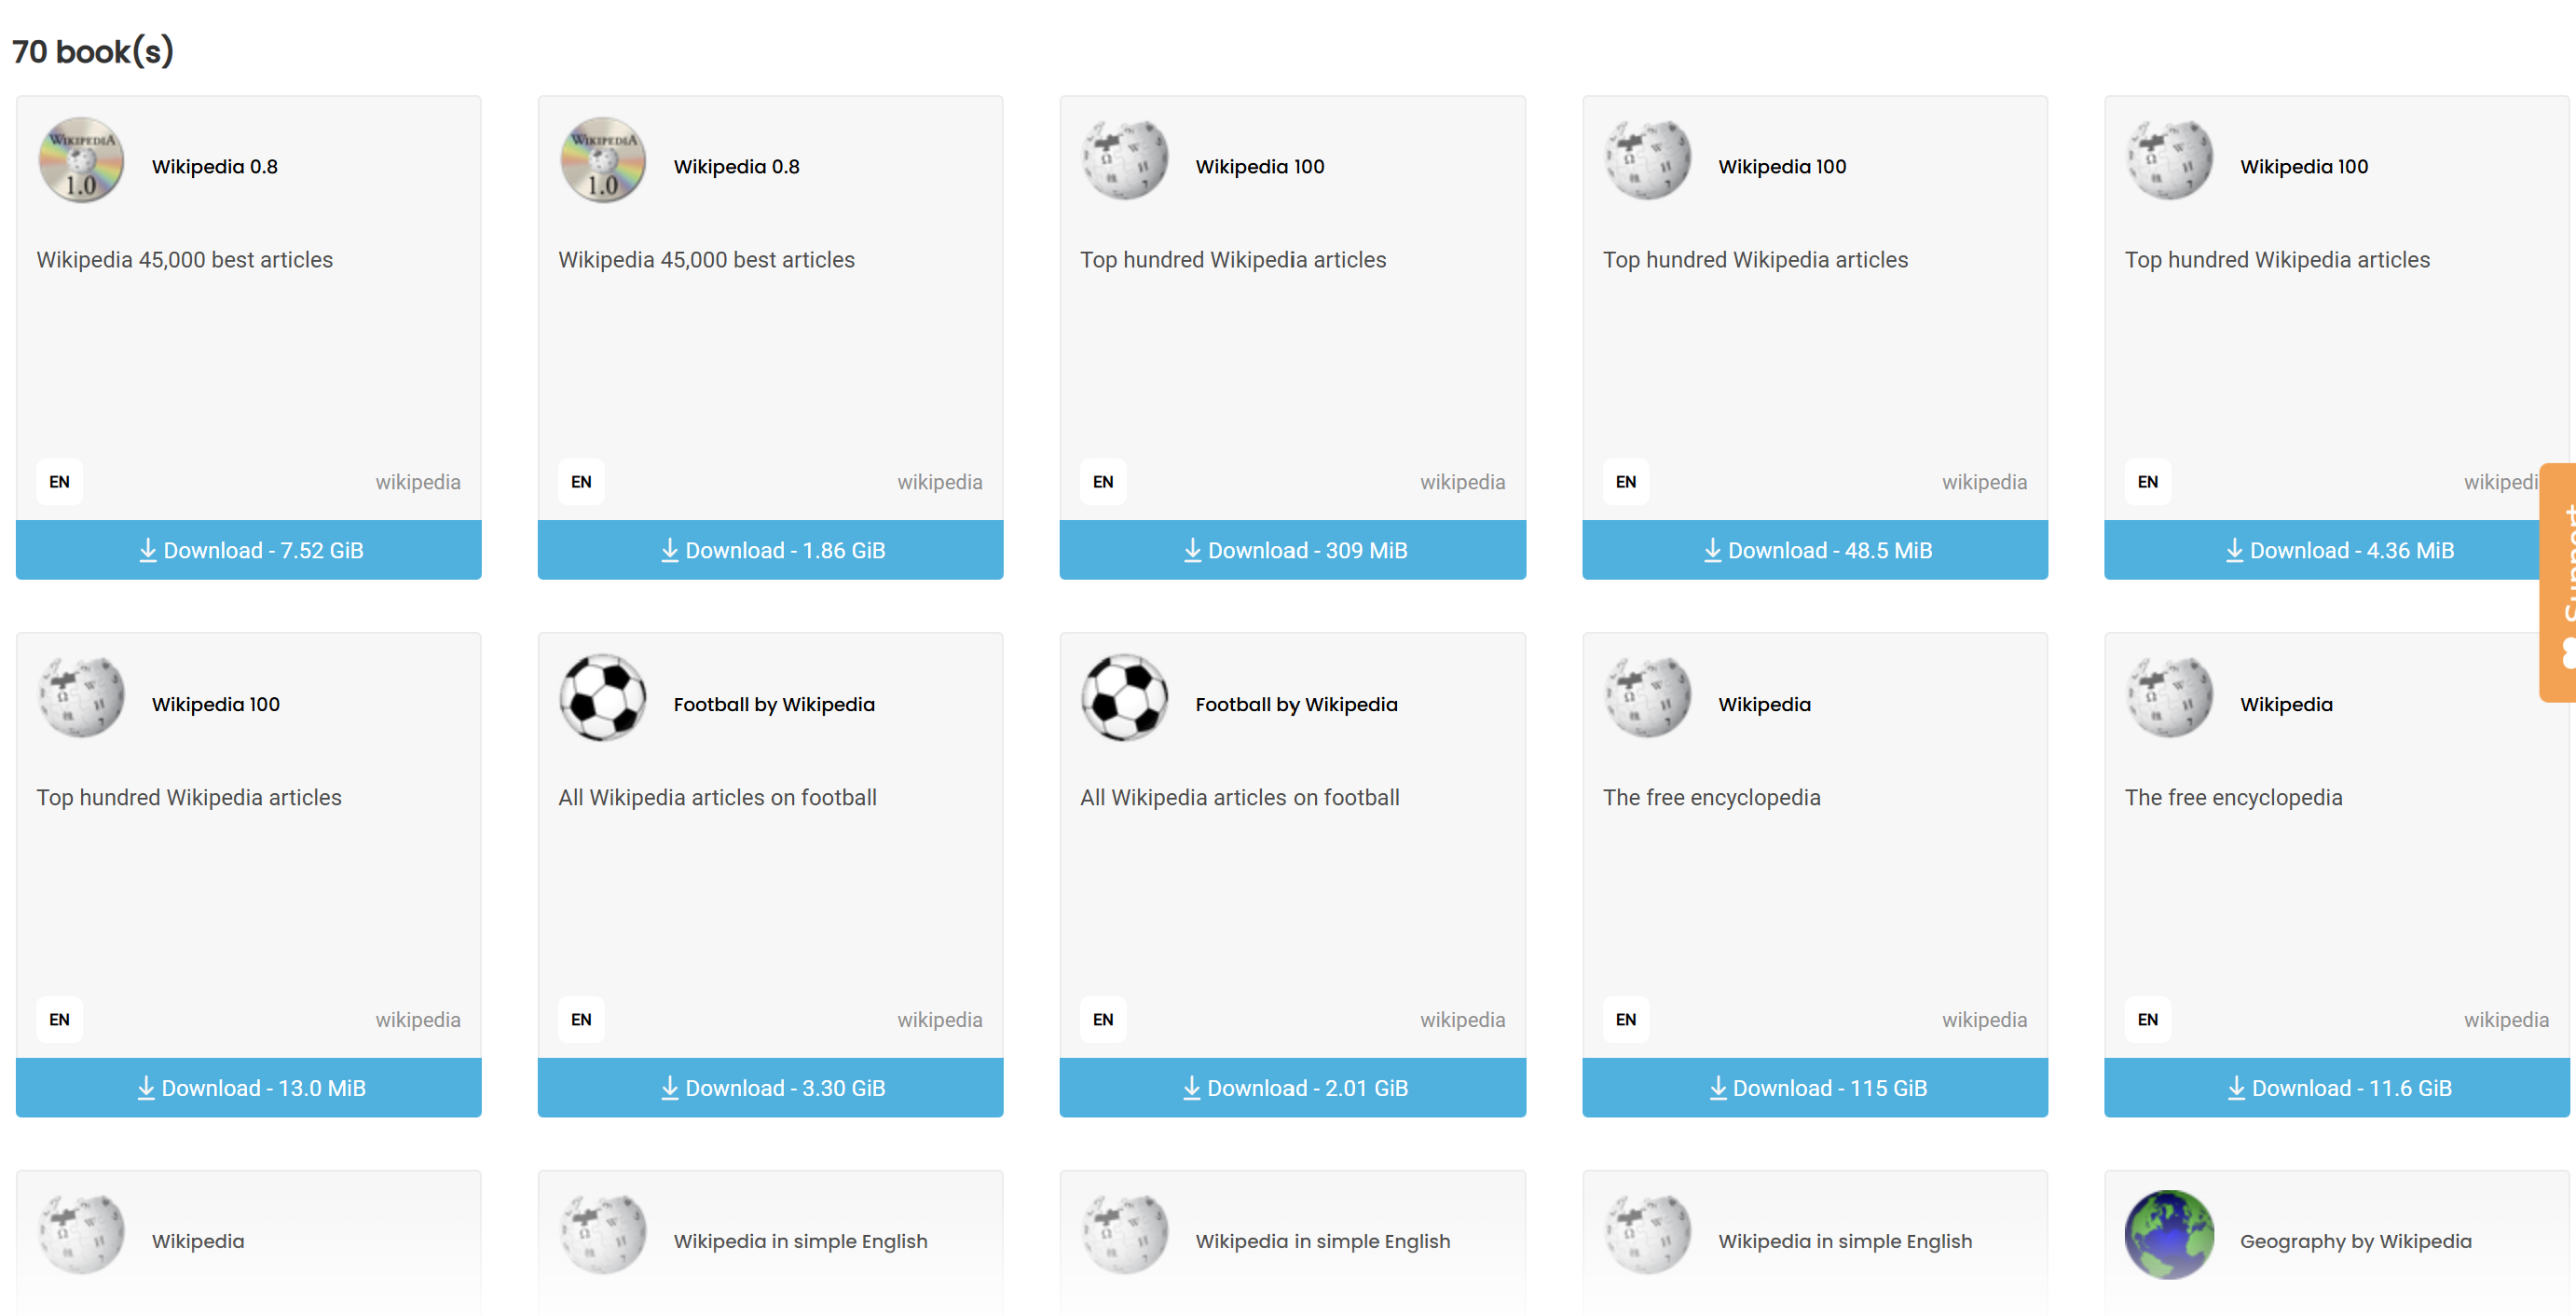

From the image, it is possible to see collections like "Top hundred Wikipedia articles". We searched for small, focused files and ran several tests. However, this approach presented multiple issues that ultimately led to its deprecation:

1. **Large Article Size:** Even when using files with tables and images automatically removed, the articles remained too large, making database ingestion extremely slow. Consequently, we decided to use only the first five paragraphs of each article.
2. **Poor Information Quality:** Even after restricting the text to five paragraphs, the resulting chunks lacked the necessary information to effectively answer most questions.
3. **Complex Preprocessing Pipeline:** Transforming and cleaning a document from a `.zim` file into a usable `Document` object for ChromaDB required the `libzim` module to read the file and `BeautifulSoup` to parse the HTML. This per-document processing was prohibitively time-consuming.

> **Note:** This approach is still implemented and can be found at: `src/guesser/ingestion/extractor/zim_extractor.py`

---

### Second Approach: Hugging Face QA Datasets

Compared to KIWIX, this approach proved significantly better due to:

1. **Focused Datasets:** We found Question & Answer (QA) datasets containing highly relevant and objective information.
2. **Clean Data:** The data was already structured and clean, typically consisting of dedicated text columns for questions and answers.

The datasets used are categorized as follows:

**Science and Nature**
* **SCIQ Dataset:** [allenai/sciq](https://huggingface.co/datasets/allenai/sciq)
* **ARXIV-physics:** [gallen881/arxiv-physics](https://huggingface.co/datasets/gallen881/arxiv-physics)
* **Camel-ai Physics:** [camel-ai/physics](https://huggingface.co/datasets/camel-ai/physics)
* **Camel-ai Chemistry:** [camel-ai/chemistry](https://huggingface.co/datasets/camel-ai/chemistry)
* **Camel-ai Biology:** [camel-ai/biology](https://huggingface.co/datasets/camel-ai/biology)

**Ancient History and Politics**
* **kth8 OpenTriviaQA** *(History and World topics only)*: [kth8/OpenTriviaQA](https://huggingface.co/datasets/kth8/OpenTriviaQA)
* **CoT Reasoning - The Ancient Past:** [mattwesney/CoT_Reasoning_The_Ancient_Past](https://huggingface.co/datasets/mattwesney/CoT_Reasoning_The_Ancient_Past)

**Entertainment**
* **kth8 OpenTriviaQA** *(Entertainment topics)*: [kth8/OpenTriviaQA](https://huggingface.co/datasets/kth8/OpenTriviaQA)

**Philosophy and Psychology**
* **Philosophia-QA:** [bingbangboom/philosophia-QA](https://huggingface.co/datasets/bingbangboom/philosophia-QA)
* **Psychology Question Answer:** [BoltMonkey/psychology-question-answer](https://huggingface.co/datasets/BoltMonkey/psychology-question-answer)

While *Science and Nature* has abundant data sources on Hugging Face, themes like *Ancient History* and *Entertainment* lacked sufficient datasets, posing a significant challenge for the RAG approach. After several tests, it became clear that the Ancient History datasets were yielding irrelevant context, prompting the decision to remove this theme from the RAG pipeline.

---

### Summary

* **Science:** Possesses the strongest local corpus (103k+ chunks).
* **Entertainment:** Has a decent corpus (~25k trivia Q&A pairs).
* **Philosophy/Psychology:** Has a decent corpus (~25k trivia Q&A pairs).
* **History:** Initially utilized RAG, but was removed due to poor context quality. It is now handled by alternative strategies.
* **News and Math:** Handled by alternative strategies (detailed in subsequent sections).

Current state of the database:

In [5]:
import chromadb

db_path = os.path.join(marcelo_root, 'src', 'guesser', 'context_db')
client = chromadb.PersistentClient(path=db_path)

print(f'{'Collection':<28}{'Documents':>12}')
print('-' * 42)
for col in client.list_collections():
    print(f'{col.name:<28}{col.count():>12,}')

Collection                     Documents
------------------------------------------
history_politics                  13,469
entertainment                     25,318
news                                   0
maths                              8,041
science_and_nature               103,842
philosophy_psychology                  0


### Embedding model

All chunks are embedded with **`nomic-embed-text`** (~600 MB). This model runs locally via Ollama and is shared across all RAG queries. 

Ingestion happens out-of-band (one-time scripts in `Marcelo/scripts/`):
- `mass_ingest.py` — bulk-load from ZIM/Wikipedia archives
- `dataset_mass_ingest.py` — pull from HuggingFace datasets (e.g., `kth8/OpenTriviaQA`, `camel-ai/chemistry`)
- `recreate_db.py` — reset and recreate empty collections


## Part 4 — Strategy 1: RAG (Retrieval-Augmented Generation)

Used for **Science**, **Entertainment**, and **Philosophy**.

### Full pipeline

```
Question
   │
   ▼
┌─────────────────────┐
│  QueryTranslator    │  qwen2.5:0.5b — extracts 1-3 keywords
└─────────────────────┘
   │
   ▼
┌─────────────────────┐
│   Retriever (RAG)   │  Two-vector search: keywords + full prompt
└─────────────────────┘
   │                       │
   ▼                       ▼
  RRF fusion + similarity threshold filter
   │
   ▼
┌─────────────────────┐
│   LLM (llama3.2)    │  Primary: 1b (with context) → Fallback: latest (no chunks)
└─────────────────────┘
   │
   ▼
Answer index (0-3)
```

### Key tricks

1. **Query translation**: a tiny 0.5B model turns a verbose question into search-friendly keywords. Reduces noise in the embedding query.
2. **Two-vector search + RRF**: we embed BOTH the translated keywords AND the full question, run two searches in parallel, then fuse with **Reciprocal Rank Fusion** (RRF). Catches different facets of relevance.
3. **Similarity threshold**: chunks below threshold are dropped. If nothing passes, we go to the **fallback model** (larger, no context).
4. **Cascade model selection**: small model (llama3.2:1b) when good context is found; bigger model (llama3.2:latest) when relying on internal knowledge.

In [7]:
from src.guesser.engine.query_translator import QueryTranslator

translator = QueryTranslator(model_name='qwen2.5:0.5b')

example_question = 'Air is composed of many different substances. Which of the following components of air is a compound rather than an element?'
keywords = translator.translate(example_question)
print(f'Original: {example_question}')
print(f'Keywords: {keywords}')

 [Translator] Raw: "Air is composed of many different substances. Whic..." -> Keywords: "Air, elements, compounds"
Original: Air is composed of many different substances. Which of the following components of air is a compound rather than an element?
Keywords: Air, elements, compounds


In [16]:
# Now let's see the full RAG pipeline run end-to-end on a Science question.
from src.guesser.engine.guesser_engine import GuesserEngine
from src.guesser.engine.configs import EMBEDDING_MODEL, PRE_LOAD_MODELS
from src.millionaire_client.models import Question

# Instantiate the engine (this will warm up models)
engine = GuesserEngine(
    llm_model=None,
    db_path=db_path,
    embedding_model=EMBEDDING_MODEL,
    theme='Science and Nature',
    debug=True,
    pre_load_models=PRE_LOAD_MODELS,
)

science_q = Question(
    text='What is the basic SI unit for mass?',
    options=[
        'gram',
        'kilogram',
        'pound',
        'ounce',
    ],
)

result = engine.answer(science_q)
print('\n=== RESULT ===')
print('Answer:', result['answer'])
print(f'Total: {result["total_time"]:.2f}s | Search: {result["search_time"]:.2f}s | Reasoning: {result["reasoning_time"]:.2f}s')

[DEBUG] Pre-loading models into VRAM: ['qwen2.5:0.5b', 'llama3.2:latest', 'llama3.2:latest', 'qwen2-math:1.5b']
 [Ollama] Model 'qwen2.5:0.5b' warmed up and resident in VRAM.
 [Ollama] Model 'llama3.2:latest' warmed up and resident in VRAM.
 [Ollama] Model 'llama3.2:latest' warmed up and resident in VRAM.
 [Ollama] Model 'qwen2-math:1.5b' warmed up and resident in VRAM.

--- OLLAMA VRAM DIAGNOSTIC ---
NAME               ID              SIZE      PROCESSOR    CONTEXT    UNTIL   
qwen2-math:1.5b    a4fdda0c6cc5    1.6 GB    100% CPU     4096       Forever    
llama3.2:latest    a80c4f17acd5    4.8 GB    100% CPU     4096       Forever    
qwen2.5:0.5b       a8b0c5157701    693 MB    100% CPU     4096       Forever    


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
 CRITICAL VRAM WARNING: The following models are running on CPU:
  - qwen2-math:1.5b
  - llama3.2:latest
  - qwen2.5:0.5b

 This will cause EXTREME slowness and likely TIMEOUTS.
 Your GPU VRAM is likely full. Co

TypeError: Question.__init__() missing 1 required positional argument: 'id'

## Part 5 — Strategy 2: Web Search

Used for **History** and **News** — themes where:
- The local knowledge corpus is too small or absent
- The information may be time-sensitive (especially News)

We replace ChromaDB retrieval with a **DuckDuckGo** query, then inject the top snippets as context. The LLM (`llama3.2:latest`) then picks the answer.

### Why DuckDuckGo?
- No API key required (free, public)
- Returns clean title + snippet + URL triples
- Reasonable latency (~1-3s per query)

### Why not for everything?
- Not the idea of this approach, it's working more as a fallback for situations that we cannot find information.
- Rate limits with many sequential queries
- Adds 1-3s latency vs cached local RAG
- Snippets can be noisy (homepages, unrelated content)

In [8]:
from src.guesser.engine.utils.web_search import web_search

snippets = web_search(
    'Who was the first president of the United States?',
    max_results=3,
    debug=True,
)
print('\n=== AGGREGATED CONTEXT ===')
print(snippets[:600], '...')

[DEBUG] WebSearch query: 'Who was the first president of the United States?'
[DEBUG] WebSearch max_results: 3
[DEBUG] WebSearch got 3 snippets in 1.82s
[DEBUG]   [0] George Washington - Wikipedia
[DEBUG]       George Washington ... George Washington (February 22, 1732 [O.S. February 11, 1731] [a] – December 14, 1799) was a Founding Father and the first president of the United States, serving from 1789 to 17
[DEBUG]       https://en.m.wikipedia.org/wiki/George_Washington
[DEBUG]   [1] List of presidents of the United States | U.S. Presidents, Presidential ...
[DEBUG]       What Happens if the President Dies? If the president of the United States dies, the vice president immediately assumes the office of president. The Twenty-fifth Amendment to the U.S. Constitution, rat
[DEBUG]       https://www.britannica.com/topic/Presidents-of-the-United-States-1846696
[DEBUG]   [2] Before the White House: Who Really Was America’s First President?
[DEBUG]       Learn how George Washington became the 

In [18]:
# Run a full News question through the engine
engine.set_theme('News')

news_q = Question(id=1,
    text='Which country hosted the 2024 Summer Olympics?',
    options=[
        'Japan',
        'France',
        'Brazil',
        'Australia',
    ],
)

result = engine.answer(news_q)
print('\n=== RESULT ===')
print('Answer:', result['answer'])
print(f'Total: {result["total_time"]:.2f}s | Search: {result["search_time"]:.2f}s | Reasoning: {result["reasoning_time"]:.2f}s')

AttributeError: 'str' object has no attribute 'text'

## Part 6 — Math.

### Architecture

```text
Math Question
    │
    ▼
┌─────────────────────┐
│  MathClassifier     │  qwen2.5:0.5b — outputs 'calculation' or 'theory'
└─────────────────────┘
    │
    ├── calculation ──► ┌────────────────────┐
    │                   │  PoT prompt        │  qwen2-math:1.5b
    │                   │  (generate Python) │
    │                   └────────────────────┘
    │                             │
    │                             ▼
    │                   ┌────────────────────┐
    │                   │  code_executor     │  Run code in sandbox with sympy/numpy
    │                   │  + retry loop      │  Up to 3 attempts
    │                   └────────────────────┘
    │
    └── theory ───────► ┌────────────────────┐
                        │  Direct inference  │  llama3.2:latest
                        │  (no code)         │
                        └────────────────────┘
```

### The Problem
While for the other themes there were viable workarounds for LLM limitations (using RAG or web search, for example), Math is a separate case. The core issue here is that there are no readily available answers that we can simply retrieve from an article or a QA dataset for the vast majority of mathematical problems.

### Computational vs. Theory Questions
Within the math theme, there are two types of questions. "Theory" questions are similar to general knowledge queries; the exact answer can often be found in a document or article, making them suitable for standard RAG approaches. 

The other type involves computational calculus or arithmetic. To handle these questions, the LLM must deduce and develop the entire solution step-by-step. For an LLM, "thinking" translates to generating text tokens. The bottleneck is that local CPUs have a low token generation speed, causing the LLM to hit timeout limits before completing the solution. Furthermore, since we are using smaller, quantized models, they tend to hallucinate during intermediate steps, often forgetting to output a single definitive answer and instead generating a convoluted (and typically incorrect) block of text.

### Chain of Thought (CoT): The Initial Approach
The first strategy to help the LLM organize its reasoning was to use a Chain of Thought (CoT) prompt, encouraging the model to work through the problem step-by-step to arrive at an answer. This approach failed entirely—not strictly due to accuracy, but because the model would *never* finish generating the answer within the time constraints. Inference times were averaging 50-60 seconds per question, resulting in a 0% success rate due to timeouts.

### Program of Thought (PoT): The Solution
To bypass the slow token generation issue, I implemented a technique known as Program of Thought (PoT). Instead of reasoning in plain text, the LLM is prompted to write a Python script to solve the math problem. This code is then executed in an isolated local sandbox environment. 

This architectural shift drastically reduces the number of tokens the LLM needs to generate. Consequently, we eliminated the timeout errors. While the base accuracy was still inconsistent due to the model size, the execution pipeline allows for automated retry loops.

### Agentic Separation
Because we have two fundamentally different approaches depending on the type of math question, a small classifier model (qwen2.5:0.5b) is placed at the entry point. It is responsible for analyzing the question and deciding whether it is a "computational" or "theory" problem. Based on this classification, the system routes the request to a specific prompt and a specialized model tailored for that task. 

> **Note:** The prompts for these distinct flows can be found at `src/guesser/engine/prompts.py`.

In [10]:
# Demo the math classifier
from src.guesser.engine.utils.math_classifier import MathClassifier

classifier = MathClassifier(model_name='qwen2.5:0.5b', debug=True)

test_questions = [
    'What is the integral of x^2 from 0 to 5?',
    'Who proved Fermat\'s Last Theorem?',
    'Solve the equation 2x + 7 = 15',
    'What is the definition of a prime number?',
]

for q in test_questions:
    label = classifier.classify(q)
    print(f'  [{label:<11}] {q}')

[DEBUG] MathClassifier model: qwen2.5:0.5b
[DEBUG] MathClassifier question: What is the integral of x^2 from 0 to 5?...
[DEBUG] MathClassifier raw='theory' -> 'theory' (latency 3.53s)
  [theory     ] What is the integral of x^2 from 0 to 5?
[DEBUG] MathClassifier model: qwen2.5:0.5b
[DEBUG] MathClassifier question: Who proved Fermat's Last Theorem?...
[DEBUG] MathClassifier raw='theory' -> 'theory' (latency 0.28s)
  [theory     ] Who proved Fermat's Last Theorem?
[DEBUG] MathClassifier model: qwen2.5:0.5b
[DEBUG] MathClassifier question: Solve the equation 2x + 7 = 15...
[DEBUG] MathClassifier raw='calculation' -> 'calculation' (latency 0.31s)
  [calculation] Solve the equation 2x + 7 = 15
[DEBUG] MathClassifier model: qwen2.5:0.5b
[DEBUG] MathClassifier question: What is the definition of a prime number?...
[DEBUG] MathClassifier raw='theory' -> 'theory' (latency 0.29s)
  [theory     ] What is the definition of a prime number?


In [13]:
# Demo the code executor independently
from src.guesser.engine.utils.code_executor import execute_pot_code

# Pretend an LLM produced this code block:
fake_llm_output = '''Here is the solution:

```python
from sympy import symbols, integrate
x = symbols('x')
result = integrate(x**2, (x, 0, 5))
# Result should match one of the options
options = ["125/3", "25", "41.6", "100"]
ans = str(result)
print(PYTHON_OPTIONS.index(ans) if ans in PYTHON_OPTIONS else 0)
```
'''

options = ['125/3', '25', '41.6', '100']
index = execute_pot_code(fake_llm_output, options=options)
print(f'Executor returned index: {index} → option: {options[index]}')

Executor returned index: 0 → option: 125/3


In [ ]:
# Now run a Math question through the full engine (classifier → PoT → executor → result)
engine.set_theme('Maths')

math_q = Question(
    text='If a train travels 60 km/h for 2.5 hours, how many kilometers does it travel?',
    options=[
        QuestionOption(text='120'),
        QuestionOption(text='150'),
        QuestionOption(text='180'),
        QuestionOption(text='100'),
    ],
)

result = engine.answer(math_q)
print('\n=== RESULT ===')
print('Answer:', result['answer'])
print(f'Total: {result["total_time"]:.2f}s | Reasoning: {result["reasoning_time"]:.2f}s')

## Part 7 — The Integrated Engine

All strategies live inside a single `GuesserEngine` class. The engine:

1. Pre-loads the relevant models into Ollama at startup (and keeps them warm with `keep_alive=-1`)
2. Caches per-theme state (retriever, prompt, LLM handle) in `theme_cache` to avoid re-instantiation when switching themes
3. Dynamically swaps to the **fallback model** when RAG returns no usable chunks
4. Wraps everything in a `try/finally` so that per-question state overrides (e.g., the Math sub-router switching to theory mode) get cleanly restored

The high-level `MarceloGuesser` class is a thin wrapper that adapts `GuesserEngine` outputs to the quiz client's expected format (single integer 0-3) and applies the random fallback parser.

In [14]:
# Inspect the cached themes after running a few questions
print('Themes currently cached in engine:')
for theme_name in engine.theme_cache.keys():
    print(f'  - {theme_name}')

print(f'\nCurrent active theme: {engine.theme}')
print(f'Current approach:     {engine.approach_type.value}')

Themes currently cached in engine:


NameError: name 'engine' is not defined

In [ ]:
# Round-trip demo: send one question per theme through the same engine instance
from src.models import ExperimentConfig
from src.guesser.marcelo_guesser import MarceloGuesser

config = ExperimentConfig(username='notebook_demo', debug=False)
guesser = MarceloGuesser(config=config, db_path=db_path, theme='Science and Nature')

demo_questions = [
    ('Science and Nature',          'What is the speed of light in vacuum?', ['3e8 m/s', '3e6 m/s', '3e10 m/s', '3e5 m/s']),
    ('Entertainment',               'Who directed the film Pulp Fiction?',   ['Scorsese', 'Tarantino', 'Coppola', 'Spielberg']),
    ('Philosophy and Psychology',   'Who wrote The Republic?',               ['Aristotle', 'Plato', 'Socrates', 'Kant']),
    ('Ancient History and Politics','Who was the first emperor of Rome?',    ['Caesar', 'Augustus', 'Nero', 'Trajan']),
    ('News',                        'Which country hosted Euro 2024?',       ['UK', 'Germany', 'Italy', 'Spain']),
    ('Maths',                       'What is 12 * 12?',                      ['124', '144', '142', '154']),
]

for theme, text, opts in demo_questions:
    q = Question(text=text, options=[QuestionOption(text=o) for o in opts])
    try:
        answer = guesser.infer_answer(q, theme=theme)
        print(f'[{theme:<32}] Q: {text}')
        print(f'{"":<34} → Answer: option {answer} = "{opts[answer]}"')
    except Exception as e:
        print(f'[{theme:<32}] ERROR: {e}')

## Part 8 — Conclusions

As highlighted throughout this notebook, the primary objective was not necessarily to achieve a perfect score (correctly guessing all 15 questions), but rather to explore the limits of local LLM execution under strict hardware constraints, especially since other team members were already investigating cloud-based approaches using Google Colab.

### CHARTS


### Conclusions

* **Mixed RAG Performance:** Counterintuitively, the implementation of RAG sometimes degraded the guesser's performance. This occurred primarily due to the increased prompt size from the injected context, which frequently led to timeouts. Furthermore, the retrieved context was occasionally irrelevant because not every category has a high-quality, comprehensive database. However, for the *Science and Nature* theme (the largest database), RAG proved to be a critical and effective feature, as the LLM successfully leveraged the retrieved information to improve accuracy.

* **The Math Bottleneck:** Math remains a severe challenge. Under the current hardware and time constraints, answering math questions consistently appears unfeasible. Using smaller models avoids timeouts but frequently results in hallucinated or incorrect arithmetic. Conversely, using larger, more capable models inevitably triggers timeouts. Despite exhaustive efforts to optimize this pipeline (such as the PoT approach), hardware limitations remain a hard blocker for complex local mathematical inference.

* **Thematic Agentic Separation:** Isolating the environment—routing to specific prompts and models based on the question's theme—significantly improved the overall architecture and quality of the project. This was highly effective because the API already provided the theme categorization. If we had been required to implement an additional LLM classification step to determine the theme for every question, the added processing overhead might have negated the benefits of this separation.

* **The Critical Role of Prompt Engineering:** Tailoring prompts to specific tasks proved essential. Prompt engineering allowed us to strictly enforce output formats and dictate the reasoning approach. It is crucial to align the prompt with the paradigm the model was trained on. For instance, while most math models are fine-tuned for Chain of Thought (CoT), some are specifically trained for Program of Thought (PoT). Matching the prompt architecture to the model's training significantly improves output quality. Below is an example of two highly specialized prompts used in the system:

  **Prompt for Entertainment (Direct Classification & RAG):**
```text
  QA_PROMPT_TMPL_STR_ENTERTAINMENT = (
      "You are an expert in entertainment and pop culture. Use the context to answer the question.\n"
      "--- CONTEXT ---\n"
      "{context}\n"
      "----------------\n"
      "QUESTION:\n{question}\n\n"
      "OPTIONS:\n{options}\n\n"
      "Output ONLY the index number (0, 1, 2, or 3) of the correct answer.\n"
      "CRITICAL: Do NOT include any other text, words, or explanations. Just the DIGIT.\n\n"
      "If there's NO INFORMATION about the question in the CONTEXT, REASON with your own knowledge.\n"
      "MANDATORY: You MUST output exactly ONE digit (0, 1, 2, or 3). NEVER refuse. NEVER say 'I cannot' or 'I don't know'. If uncertain, output your best guess as a single digit.\n"
      "Final Option Index: "
  )
  ```

**Prompt for Math (Program of Thought / Code Generation):**
```text
  QA_PROMPT_TMPL_STR_MATHS_POT = (
      "Solve this math problem using Python. Output ONLY one ```python code block.\n\n"
      "{context}"
      "QUESTION: {question}\n\n"
      "OPTIONS: {options}\n\n"
      "Environment (already available):\n"
      "- `from sympy import *` (symbols, solve, integrate, diff, Matrix, etc.)\n"
      "- `import math, statistics`\n"
      "- `PYTHON_OPTIONS = {options_list}` (list of option strings)\n\n"
      "Rules:\n"
      "- Compute the answer numerically or symbolically.\n"
      "- Last line MUST be `print(index)` where index is 0, 1, 2, or 3.\n\n"
      "Example:\n"
      "```python\n"
      "from sympy import *\n"
      "x = symbols('x')\n"
      "result = solve(x**2 - 4, x)\n"
      "ans = float(max(result))\n"
      "print(PYTHON_OPTIONS.index(str(int(ans))) if str(int(ans)) in PYTHON_OPTIONS else 0)\n"
      "
```\n\n"
      "Your solution:\n"
  )
  ```

* **Few-Shot Prompting Limitations:** While few-shot prompting is generally a powerful technique, it proved unviable in this specific setup. For very small models, concatenating few-shot examples alongside the RAG context quickly saturates the context window. This cognitive overload caused the smaller models to hallucinate, lose track of the core instructions, and completely fail to adhere to the mandatory output format constraints.